# Data Analysis Pipeline for Clustered Mouse Aging Data

In [447]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy as sp
import re
from collections import Counter
from copy import deepcopy
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import os
import ast
from scipy import stats 
from scipy.odr import Model, RealData, ODR
from scipy.stats import spearmanr, wilcoxon, ttest_1samp, ranksums, gaussian_kde, fisher_exact, ttest_ind, kruskal, mannwhitneyu, binomtest
from matplotlib import gridspec
from matplotlib_venn import venn3
import zipfile
from glob import glob
import gzip
import tarfile
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as mpatches
from itertools import combinations
import pingouin as pg

print("packages have been successfully read in!")

packages have been successfully read in!


In [448]:
## Setting directories and reading in data 
# Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample 
# For reproducing analysis of the following datasets, it is highly recommended to maintain the same project directory structure... 

print("loading directories...")
CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'
PROJ_DIR        = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'
SUPP_DIR        = PROJ_DIR + 'Supplementary_Tables/'
RAW_DIR         = PROJ_DIR + 'Raw_Quant/AgedMouse/'
INDIR           = PROJ_DIR + 'Analysis_Inputs/'
OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/'
DEPDIR          = CODE_DIR + 'Dependencies/'
FRAG_DIR        = PROJ_DIR + 'frag_output/'   # FragPipe: <Tissue>/<tissue>_1/ holds psm.tsv + per-fraction *.tsv
PLOT_DIR        = PROJ_DIR + 'Plots/AgedMouse/'

# Dataset specific general dirs
Takasugi_INDIR           = INDIR + 'Takasugi_2024/'
Takasugi_OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/Takasugi_2024/'
Takasugi_DEPDIR          = CODE_DIR + 'Dependencies/Takasugi_2024/'
Takasugi_FRAG_DIR        = PROJ_DIR + 'frag_output/Takasugi_2024/'   # FragPipe: <Tissue>/<tissue>_1/ holds psm.tsv + per-fraction *.tsv
Takasugi_PLOT_DIR        = PROJ_DIR + 'Plots/Takasugi_2024/'

Tsumagari_INDIR          = INDIR + 'Tsumagari_2023/'    
Tsumagari_OUTDIR         = CODE_DIR + 'Dependencies/Analysis_Outputs/Tsumagari_2023/'
Tsumagari_DEPDIR         = CODE_DIR + 'Dependencies/Tsumagari_2023/'
Tsumagari_FRAG_DIR       = PROJ_DIR + 'frag_output/Tsumagari_2023/'   # FragPipe: <Tissue>/<tissue>_1/ holds psm.tsv + per-fraction *.tsv
Tsumagari_PLOT_DIR       = PROJ_DIR + 'Plots/Tsumagari_2023/'

# Keele_INDIR              = INDIR + 'Keele_2025/'    
# Keele_OUTDIR             = CODE_DIR + 'Dependencies/Analysis_Outputs/Keele_2025/'
# Keele_DEPDIR             = CODE_DIR + 'Dependencies/Keele_2025/'
# Keele_FRAG_DIR           = PROJ_DIR + 'frag_output/Keele_2025/'   # FragPipe: <Tissue>/<tissue>_1/ holds psm.tsv + per-fraction *.tsv
# Keele_PLOT_DIR           = PROJ_DIR + 'Plots/Keele_2025/'

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(SUPP_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)


## Define dataset/TMT set folders 

# Takasugi et al., 2024
#S1 AORTA
aorta_proj_dir      = Takasugi_OUTDIR + 'Aorta/'
aorta_aa_subs_dir   = Takasugi_INDIR + 'Aorta/'
aorta_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_aorta.xlsx')
aorta_samples       = ['S'+str(i) for i in list(set(aorta_sample_map['TMT plex']))]
aorta_frag            = Takasugi_FRAG_DIR + 'Aorta/aorta_1/'

#S2 BRAIN 
brain_proj_dir      = Takasugi_OUTDIR + 'Brain/'
brain_aa_subs_dir   = Takasugi_INDIR + 'Brain/'
brain_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_brain.xlsx')
brain_samples       = ['S'+str(i) for i in list(set(brain_sample_map['TMT plex']))]
brain_frag            = Takasugi_FRAG_DIR + 'Brain/brain_1/'

#S3 HEART
heart_proj_dir      = Takasugi_OUTDIR + 'Heart/'
heart_aa_subs_dir   = Takasugi_INDIR + 'Heart/'
heart_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_heart.xlsx')
heart_samples       = ['S'+str(i) for i in list(set(heart_sample_map['TMT plex']))]
heart_frag            = Takasugi_FRAG_DIR + 'Heart/heart_1/'

#S4 KIDNEY
kidney_proj_dir      = Takasugi_OUTDIR + 'Kidney/'
kidney_aa_subs_dir   = Takasugi_INDIR + 'Kidney/'
kidney_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_kidney.xlsx')
kidney_samples       = ['S'+str(i) for i in list(set(kidney_sample_map['TMT plex']))]
kidney_frag            = Takasugi_FRAG_DIR + 'Kidney/kidney_1/'

#S5 LIVER
liver_proj_dir      = Takasugi_OUTDIR + 'Liver/'
liver_aa_subs_dir   = Takasugi_INDIR + 'Liver/'
liver_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_liver.xlsx')
liver_samples       = ['S'+str(i) for i in list(set(liver_sample_map['TMT plex']))]
liver_frag            = Takasugi_FRAG_DIR + 'Liver/liver_1/'   

#S6 LUNG
lung_proj_dir      = Takasugi_OUTDIR + 'Lung/'
lung_aa_subs_dir   = Takasugi_INDIR + 'Lung/'
lung_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_lung.xlsx')
lung_samples       = ['S'+str(i) for i in list(set(lung_sample_map['TMT plex']))]
lung_frag            = Takasugi_FRAG_DIR + 'Lung/lung_1/'

#S7 MUSCLE
muscle_proj_dir      = Takasugi_OUTDIR + 'Muscle/'
muscle_aa_subs_dir   = Takasugi_INDIR + 'Muscle/'
muscle_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_muscle.xlsx')
muscle_samples       = ['S'+str(i) for i in list(set(muscle_sample_map['TMT plex']))]
muscle_frag            = Takasugi_FRAG_DIR + 'Muscle/muscle_1/'

#S8 SKIN
skin_proj_dir      = Takasugi_OUTDIR + 'Skin/'
skin_aa_subs_dir   = Takasugi_INDIR + 'Skin/'
skin_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_skin.xlsx')
skin_samples       = ['S'+str(i) for i in list(set(skin_sample_map['TMT plex']))]
skin_frag            = Takasugi_FRAG_DIR + 'Skin/skin_1/'   


# # Keele et al., 2025 
# # Cortex_1 
# cortex_keele_proj_dir      = Keele_OUTDIR + 'Cortex/'
# cortex_keele_aa_subs_dir   = Keele_INDIR + 'Cortex/'
# cortex_keele_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_cortex_keele.xlsx')
# cortex_keele_samples       = ['S'+str(i) for i in list(set(cortex_keele_sample_map['TMT plex']))]
# cortex_keele_frag            = Keele_FRAG_DIR + 'Cortex/cortex_1/'

# # Striatum
# striatum_keele_proj_dir      = Keele_OUTDIR + 'Striatum/'
# striatum_keele_aa_subs_dir   = Keele_INDIR + 'Striatum/'
# striatum_keele_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_striatum_keele.xlsx')
# striatum_keele_samples       = ['S'+str(i) for i in list(set(striatum_keele_sample_map['TMT plex']))]
# striatum_keele_frag            = Keele_FRAG_DIR + 'Striatum/striatum_1/'

# # Hippocampus_1 
# hippocampus_keele_proj_dir      = Keele_OUTDIR + 'Hippocampus/'
# hippocampus_keele_aa_subs_dir   = Keele_INDIR + 'Hippocampus/'
# hippocampus_keele_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_hippocampus_keele.xlsx')
# hippocampus_keele_samples       = ['S'+str(i) for i in list(set(hippocampus_keele_sample_map['TMT plex']))]
# hippocampus_keele_frag            = Keele_FRAG_DIR + 'Hippocampus/hippocampus_1/'

# # Kidney_2
# kidney_keele_proj_dir      = Keele_OUTDIR + 'Kidney/'
# kidney_keele_aa_subs_dir   = Keele_INDIR + 'Kidney/'
# kidney_keele_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_kidney_keele.xlsx')
# kidney_keele_samples       = ['S'+str(i) for i in list(set(kidney_keele_sample_map['TMT plex']))]
# kidney_keele_frag            = Keele_FRAG_DIR + 'Kidney/kidney_1'


# Tsumagari et al., 2023 
# Cortex_1
tsumagari_cortex_1_proj_dir      = Tsumagari_OUTDIR + 'cortex_1/'
tsumagari_cortex_1_aa_subs_dir   = Tsumagari_INDIR + 'cortex_1/'
tsumagari_cortex_1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_cortex_1_tsumagari.xlsx')
tsumagari_cortex_1_samples       = ['S'+str(i) for i in list(set(tsumagari_cortex_1_sample_map['TMT plex']))]
tsumagari_cortex_1_frag            = Tsumagari_FRAG_DIR + 'cortex_1/cortex_1_tsumagari_1/'

# Cortex_2
tsumagari_cortex_2_proj_dir      = Tsumagari_OUTDIR + 'cortex_2/'
tsumagari_cortex_2_aa_subs_dir   = Tsumagari_INDIR + 'cortex_2/'
tsumagari_cortex_2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_cortex_2_tsumagari.xlsx')
tsumagari_cortex_2_samples       = ['S'+str(i) for i in list(set(tsumagari_cortex_2_sample_map['TMT plex']))]
tsumagari_cortex_2_frag            = Tsumagari_FRAG_DIR + 'cortex_2/cortex_2_tsumagari_1/'

# Hippocampus_1 
tsumagari_hippocampus_1_proj_dir      = Tsumagari_OUTDIR + 'hippocampus_1/'
tsumagari_hippocampus_1_aa_subs_dir   = Tsumagari_INDIR + 'hippocampus_1/'
tsumagari_hippocampus_1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_hippocampus_1_tsumagari.xlsx')
tsumagari_hippocampus_1_samples       = ['S'+str(i) for i in list(set(tsumagari_hippocampus_1_sample_map['TMT plex']))]
tsumagari_hippocampus_1_frag            = Tsumagari_FRAG_DIR + 'hippocampus_1/hippocampus_1_tsumagari_1/'

# Hippocampus_2
tsumagari_hippocampus_2_proj_dir      = Tsumagari_OUTDIR + 'hippocampus_2/'
tsumagari_hippocampus_2_aa_subs_dir   = Tsumagari_INDIR + 'hippocampus_2/'
tsumagari_hippocampus_2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_hippocampus_2_tsumagari.xlsx')
tsumagari_hippocampus_2_samples       = ['S'+str(i) for i in list(set(tsumagari_hippocampus_2_sample_map['TMT plex']))]
tsumagari_hippocampus_2_frag            = Tsumagari_FRAG_DIR + 'hippocampus_2/hippocampus_2_tsumagari_1/'



## Lists to quickly index dataset-specific sample maps just from dataset name 
datasets = ['Aorta', 'Brain', 'cortex_1', 'cortex_2', 'hippocampus_1', 'hippocampus_2', 'Heart', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Skin']
data_dir_list = [aorta_aa_subs_dir, brain_aa_subs_dir, heart_aa_subs_dir, kidney_aa_subs_dir, 
                liver_aa_subs_dir, lung_aa_subs_dir, muscle_aa_subs_dir, skin_aa_subs_dir,
                tsumagari_cortex_1_aa_subs_dir, tsumagari_cortex_2_aa_subs_dir, tsumagari_hippocampus_1_aa_subs_dir, tsumagari_hippocampus_2_aa_subs_dir]
samples_list = [aorta_samples, brain_samples, heart_samples, kidney_samples, liver_samples, lung_samples, muscle_samples, skin_samples,
                tsumagari_cortex_1_samples, tsumagari_cortex_2_samples, tsumagari_hippocampus_1_samples, tsumagari_hippocampus_2_samples]
sample_map_list = [aorta_sample_map, brain_sample_map, heart_sample_map, kidney_sample_map, liver_sample_map, lung_sample_map, muscle_sample_map, skin_sample_map,
                tsumagari_cortex_1_sample_map, tsumagari_cortex_2_sample_map, tsumagari_hippocampus_1_sample_map, tsumagari_hippocampus_2_sample_map]

# Name-keyed lookups (granular). These survive the dataset grouping/reassignment
# in the "Group Tissues Together" cell, so downstream cells can map each granular
# tissue to its own data_dir/samples by name instead of by list position.
data_dir_by_ds = dict(zip(datasets, data_dir_list))
samples_by_ds  = dict(zip(datasets, samples_list))
proj_dir_list = [aorta_proj_dir, brain_proj_dir, heart_proj_dir, kidney_proj_dir, liver_proj_dir, lung_proj_dir, muscle_proj_dir, skin_proj_dir,
                tsumagari_cortex_1_proj_dir, tsumagari_cortex_2_proj_dir, tsumagari_hippocampus_1_proj_dir, tsumagari_hippocampus_2_proj_dir]
frag_dir_list = [aorta_frag, brain_frag, heart_frag, kidney_frag, liver_frag, lung_frag, muscle_frag, skin_frag,
                tsumagari_cortex_1_frag, tsumagari_cortex_2_frag, tsumagari_hippocampus_1_frag, tsumagari_hippocampus_2_frag]


# datasets = ['Aorta', 'Brain', 'Heart', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Skin', # Takasugi, 2024
#                 'Cortex_1',' Striatum', 'Hippocampus_1', 'Kidney_2', # Keele, 2025
#                 'Cortex_2', 'Cortex_3', 'Hippocampus_2', 'Hippocampus_3'] # Tsumagari, 2023
# data_dir_list = [aorta_aa_subs_dir, brain_aa_subs_dir, heart_aa_subs_dir, kidney_aa_subs_dir, 
#                 liver_aa_subs_dir, lung_aa_subs_dir, muscle_aa_subs_dir, skin_aa_subs_dir,
#                 cortex_keele_aa_subs_dir, striatum_keele_aa_subs_dir, hippocampus_keele_aa_subs_dir, kidney_keele_aa_subs_dir,
#                 tsumagari_cortex_1_aa_subs_dir, tsumagari_cortex_2_aa_subs_dir, tsumagari_hippocampus_1_aa_subs_dir, tsumagari_hippocampus_2_aa_subs_dir]
# samples_list = [aorta_samples, brain_samples, heart_samples, kidney_samples, liver_samples, lung_samples, muscle_samples, skin_samples,
#                 cortex_keele_samples, striatum_keele_samples, hippocampus_keele_samples, kidney_keele_samples,
#                 tsumagari_cortex_1_samples, tsumagari_cortex_2_samples, tsumagari_hippocampus_1_samples, tsumagari_hippocampus_2_samples]
# sample_map_list = [aorta_sample_map, brain_sample_map, heart_sample_map, kidney_sample_map, liver_sample_map, lung_sample_map, muscle_sample_map, skin_sample_map,
#                 cortex_keele_sample_map, striatum_keele_sample_map, hippocampus_keele_sample_map, kidney_keele_sample_map,
#                 tsumagari_cortex_1_sample_map, tsumagari_cortex_2_sample_map, tsumagari_hippocampus_1_sample_map, tsumagari_hippocampus_2_sample_map]
# proj_dir_list = [aorta_proj_dir, brain_proj_dir, heart_proj_dir, kidney_proj_dir, liver_proj_dir, lung_proj_dir, muscle_proj_dir, skin_proj_dir,
#                 cortex_keele_proj_dir, striatum_keele_proj_dir, hippocampus_keele_proj_dir, kidney_keele_proj_dir,
#                 tsumagari_cortex_1_proj_dir, tsumagari_cortex_2_proj_dir, tsumagari_hippocampus_1_proj_dir, tsumagari_hippocampus_2_proj_dir]
# frag_dir_list = [aorta_frag, brain_frag, heart_frag, kidney_frag, liver_frag, lung_frag, muscle_frag, skin_frag,
#                 cortex_keele_frag, striatum_keele_frag, hippocampus_keele_frag, kidney_keele_frag,
#                 tsumagari_cortex_1_frag, tsumagari_cortex_2_frag, tsumagari_hippocampus_1_frag, tsumagari_hippocampus_2_frag]

print("directories loaded successfully!")

loading directories...
directories loaded successfully!


In [449]:
# Read in data generated from Dependencies code
# If dependencies not generated yet, go back and generate in Analysis_Dependnecies.ipynb
# Since clustering a lot of data, must combine dataframes... 

# Cluster SAAP_quant_df 
SAAP_quant_df_takasugi = pd.read_excel(Takasugi_DEPDIR+'SAAP_precursor_reporter_quant.xlsx', index_col=0)
SAAP_quant_df_tsumagari = pd.read_excel(Tsumagari_DEPDIR+'SAAP_precursor_reporter_quant.xlsx', index_col=0)
# SAAP_quant_df_keele = pd.read_excel(Keele_DEPDIR+'SAAP_precursor_reporter_quant.xlsx', index_col=0)

SAAP_quant_df_list = [SAAP_quant_df_takasugi, SAAP_quant_df_tsumagari]
SAAP_quant_df = pd.concat([SAAP_quant_df_takasugi, SAAP_quant_df_tsumagari])
SAAP_quant_df = SAAP_quant_df[SAAP_quant_df['Sample Type'] != 'Unknown'] # filter out bridges
# SAAP_quant_df['Sample Type'] = SAAP_quant_df['Sample Type'].replace({'t03mo': 't06mo'}) # group young samples together
# SAAP_quant_df['Dataset'] = SAAP_quant_df['Dataset'].str.replace(r'^(cortex|hippocampus)_\d+$', 'Brain', regex=True) # group brain samples
SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds] for ds in datasets]

print(SAAP_quant_df)

# Cluster fragment ion data 
pos_prob_df_takasugi = pd.read_csv(Takasugi_DEPDIR+'Position_probability_fragment_ion_data.csv', index_col=0)
pos_prob_df_tsumagari = pd.read_csv(Tsumagari_DEPDIR+'Position_probability_fragment_ion_data.csv', index_col=0)
# pos_prob_df_keele = pd.read_csv(Keele_DEPDIR+'Position_probability_fragment_ion_data.csv', index_col=0)

pos_prob_df_list = [pos_prob_df_takasugi, pos_prob_df_tsumagari]
pos_prob_df = pd.concat([pos_prob_df_takasugi, pos_prob_df_tsumagari])
print(pos_prob_df)

frag_dict_takasugi = pickle.load(open(Takasugi_DEPDIR+'Fragment_ion_dict.p', 'rb'))
frag_dict_tsumagari = pickle.load(open(Tsumagari_DEPDIR+'Fragment_ion_dict.p', 'rb'))
# frag_dict_keele = pd.read_pickle(Keele_DEPDIR+'Fragment_ion_dict.p', 'rb')
frag_dict = {**frag_dict_takasugi, **frag_dict_tsumagari}

frag_df_takasugi = pd.read_excel(Takasugi_DEPDIR+'fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
frag_df_tsumagari = pd.read_excel(Tsumagari_DEPDIR+'fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
# frag_df_keele = pd.read_excel(Keele_DEPDIR+'fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
frag_df = pd.concat([frag_df_takasugi, frag_df_tsumagari])
frag_df = frag_df.groupby(['Bin', 'Used'], as_index=False)['Count'].sum()
CATS = ['0', '1', '2-5', '6-10', '>10']
frag_df['Bin'] = pd.Categorical(frag_df['Bin'], categories=CATS, ordered=True)
frag_df = frag_df.sort_values('Bin').reset_index(drop=True)
# print(frag_df)

# Dataset metrics 
ds_metrics_takasugi = pd.read_excel(Takasugi_DEPDIR+'dataset_metrics.xlsx', index_col=0)
ds_metrics_tsumagari = pd.read_excel(Tsumagari_DEPDIR+'dataset_metrics.xlsx', index_col=0)
# ds_metrics_keele = pd.read_excel(Keele_DEPDIR+'dataset_metrics.xlsx', index_col=0)
ds_metrics = pd.concat([ds_metrics_takasugi, ds_metrics_tsumagari])

                  Dataset                    MTP_seq  \
Row Number                                             
0                   Aorta                   PATVSLPR   
1                   Aorta                   PATVSLPR   
2                   Aorta                   PATVSLPR   
3                   Aorta                   PATVSLPR   
4                   Aorta                   PATVSLPR   
...                   ...                        ...   
8344        hippocampus_2  EQASHLQGAVFSGAGNIAAATGLVK   
8345        hippocampus_2  EQASHLQGAVFSGAGNIAAATGLVK   
8346        hippocampus_2  EQASHLQGAVFSGAGNIAAATGLVK   
8347        hippocampus_2  EQASHLQGAVFSGAGNIAAATGLVK   
8348        hippocampus_2  EQASHLQGAVFSGAGNIAAATGLVK   

                               BP_seq  aa_sub tmt_set  Positional_probability  \
Row Number                                                                      
0                            VATVSLPR  V to P      S1                   0.991   
1                           

# 1. Filtering

## Remove immunoglobulins and trypsin-mapping SAAPs 

In [450]:
## Assign each SAAP a gene and accession & drop Igs/trypsins 

# Build dictionaries of peptide ID, gene, and accessions 
acc_gene = {}
acc_desc = {}
for frag_dir in frag_dir_list:
    cols = ['Protein ID', 'Gene', 'Protein Description', 'Mapped Proteins', 'Mapped Genes']
    psm=pd.read_csv(frag_dir +'psm.tsv', sep='\t', low_memory=False, usecols=lambda c: c in cols)

    for acc, gene, desc in zip(psm['Protein ID'], psm.get('Gene', ''), psm.get('Protein Description', '')):
        a = str(acc)
        if pd.notna(desc) and str(desc).strip():
            acc_desc.setdefault(a, str(desc).strip())
        if pd.notna(gene) and str(gene).strip():
            acc_gene.setdefault(a, str(gene).strip())
print(f'{len(acc_desc):,} reference proteins parsed from psm.tsv')

seq_to_proteins = {}
for dataset, frag_dir in zip(datasets, frag_dir_list):
    cols = ['Peptide', 'Protein', 'Mapped Proteins']
    psm=pd.read_csv(frag_dir +'psm.tsv', sep='\t', low_memory=False, usecols=lambda c: c in cols)
    for seq, prot, mapped in zip(psm['Peptide'], psm['Protein'].astype(str),
                                 psm.get('Mapped Proteins', pd.Series('')).astype(str)):
        if prot and prot != 'nan':
            full = prot if mapped in ('', 'nan') else prot + ';' + mapped.replace(', ', ';')
            seq_to_proteins.setdefault((str(dataset).lower(), seq), full)
print(f'{len(seq_to_proteins):,} unique (tissue, peptide) pairs indexed across {len(frag_dir_list)} psm.tsv files')

def prot_to_acc(protein_str):
    lead_only = True
    accs = []
    for tok in str(protein_str).split(';'):
        if tok.startswith('MTP'):
            continue
        m = re.match(r'(?:sp|tr)\|([^|]+)\|', tok) or re.match(r'^([A-Z0-9][A-Z0-9-]+)$', tok)
        if m:
            accs.append((m.group(1)))  
    accs = list(dict.fromkeys(accs))  
    return accs[:1] if lead_only else accs

row_accs = [prot_to_acc(seq_to_proteins.get((ds, bp), ''))
            for ds, bp in zip(SAAP_quant_df['Dataset'].astype(str).str.lower(), SAAP_quant_df['BP_seq'])]
row_genes = [[acc_gene.get(a, '') for a in accs] for accs in row_accs]
row_descs = [[acc_desc.get(a, '') for a in accs] for accs in row_accs]

def first_nonempty(values):
    return next((v for v in values if v), '')

# append observations to SAAP_quant_df
SAAP_quant_df['Source_accessions'] = [';'.join(accs) for accs in row_accs]
SAAP_quant_df['Source_gene']       = [first_nonempty(g) for g in row_genes]
SAAP_quant_df['Source_protein']    = [first_nonempty(d) for d in row_descs]
print(SAAP_quant_df[['MTP_seq', 'BP_seq', 'Dataset', 'Source_gene', 'Source_protein']].to_string())

12,888 reference proteins parsed from psm.tsv
752,574 unique (tissue, peptide) pairs indexed across 12 psm.tsv files
                                           MTP_seq                                  BP_seq        Dataset Source_gene                                                                                                    Source_protein
Row Number                                                                                                                                                                                                                             
0                                         PATVSLPR                                VATVSLPR          Aorta                                                                                                                              
1                                         PATVSLPR                                VATVSLPR          Aorta                                                                                  

In [451]:
# flag immunoglobulin (antibody chains) and trypsin (digestion contaminant) source proteins.
# Matching is gene- and accession-based to avoid false positives such as Ig-superfamily
# members, IgLON, anti-trypsin, or chymotrypsin.
ig_gene_re   = re.compile(r'(?i)^Ig[hkl][vjdcmage0-9]')
ig_desc_re   = re.compile(r'(?i)^(immunoglobulin|ig)[ -](heavy|kappa|lambda|gamma|mu|alpha|delta|epsilon|j)')
tryp_desc_re = re.compile(r'(?i)\btrypsin')
tryp_skip_re = re.compile(r'(?i)(anti-?trypsin|trypsin inhibitor|chymotrypsin)')
TRYPSIN_ACCESSIONS = {'P00761', 'P00760'}  # Sus scrofa / Bos taurus digestion trypsin contaminants

def is_immunoglobulin(accs):
    return any(ig_gene_re.match(acc_gene.get(a, '')) or acc_gene.get(a, '').lower() == 'jchain'
               or ig_desc_re.match(acc_desc.get(a, '')) for a in accs)

def is_trypsin(accs):
    return any(a in TRYPSIN_ACCESSIONS or
               (tryp_desc_re.search(acc_desc.get(a, '')) and not tryp_skip_re.search(acc_desc.get(a, '')))
               for a in accs)

SAAP_quant_df['immunoglobulin'] = ['YES' if is_immunoglobulin(accs) else 'NO' for accs in row_accs]
SAAP_quant_df['trypsin']        = ['YES' if is_trypsin(accs) else 'NO' for accs in row_accs]
print(f"\n{(SAAP_quant_df['immunoglobulin'] == 'YES').sum():,} SAAP observations match immunoglobulins")
print(f"{(SAAP_quant_df['trypsin'] == 'YES').sum():,} SAAP observations match trypsin")
print('immunoglobulin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].unique()))
print('trypsin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_accessions'].unique()))


64 SAAP observations match immunoglobulins
0 SAAP observations match trypsin
immunoglobulin source proteins removed: ['Ig heavy chain V region AC38 205.12', 'Immunoglobulin heavy variable V1-42', 'Immunoglobulin kappa variable 4-53', 'Immunoglobulin kappa variable 4-57 (Fragment)']
trypsin source proteins removed: []


In [452]:
# Save as Supplemental_Data_1.SAAP_quantification_aging_clustered.xlsx
SAAP_quant_df.to_excel(SUPP_DIR+'Supplemental_Data_1.SAAP_quantification_aging_clustered.xlsx')

4
0
408
          Category  Count
0  Immunoglobulins      4
1         Trypsins      0
2            SAAPs    408


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/1809934607.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Set2',alpha=1)


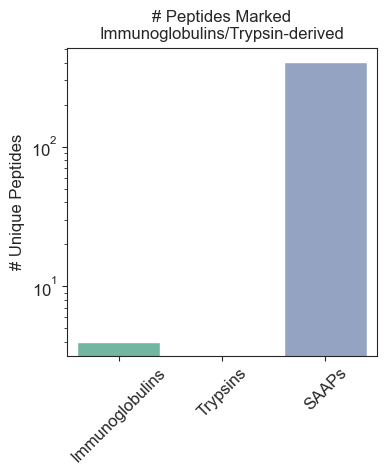

In [453]:
# Plot the number of trypsin/immunoglobulin-matching peptides 
n_immunoglobulin = SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].nunique()
print(n_immunoglobulin)

n_trypsin = SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_protein'].nunique()
print(n_trypsin)

n_main_SAAP = SAAP_quant_df.loc[(SAAP_quant_df['trypsin'] == 'NO') & (SAAP_quant_df['immunoglobulin'] == 'NO'), 'Source_protein'].nunique()
print(n_main_SAAP)

plot_df = pd.DataFrame({'Category': ['Immunoglobulins', 'Trypsins', 'SAAPs'],'Count': [n_immunoglobulin, n_trypsin, n_main_SAAP]})
print(plot_df)

plt.figure(figsize=(4,4))
sns.set_style(style='ticks')
ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='Set2',alpha=1)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('# Unique Peptides',fontsize=12)
ax.set_title('# Peptides Marked\nImmunoglobulins/Trypsin-derived',fontsize=12)
ax.tick_params(axis='x',rotation=45,labelsize=12)
ax.tick_params(axis='y',labelsize=12)

plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [454]:
drop_mask = (SAAP_quant_df['immunoglobulin'] == 'YES') | (SAAP_quant_df['trypsin'] == 'YES')
SAAP_quant_df = SAAP_quant_df.loc[~drop_mask].reset_index(drop=True)

## Rescue SAAPs with RT and spectral prediction support from positional probability filtering
A SAAP's positional probability is only high when the MS2 spectrum has the b/y ions
flanking the substituted residue. Low-abundance or poorly-fragmenting peptides often
lack those ions, so a real SAAP can score low purely from missing fragments. A hard
positional-probability cut therefore discards genuine SAAPs.

To recover them we use two orthogonal MSBooster scores from the *_edited.pin files:

  weighted_spectral_entropy : how well the observed spectrum matches the predicted
                              spectrum for the assigned SAAP (higher = better).
  delta_RT_loess            : difference between observed and predicted retention
                              time, loess-calibrated and already absolute
                              (lower = better). Orthogonal to spectral matching.

Both thresholds are calibrated against DECOYS. Each pin row has Label = 1 (target) or
-1 (decoy). We set each threshold to admit a chosen small fraction of decoys
(DECOY_ADMIT), giving every cutoff a known decoy-admission rate rather than an
arbitrary number.

Rule: keep a SAAP if it is confidently localized (positional probability >= cut),
OR if it is uncertainly localized but passes BOTH the entropy and RT thresholds.

Note: the entropy score is one-sided (it only checks the SAAP matches itself), so it
cannot reject an isobaric substitution like I<->L where the SAAP and base peptide give
the same spectrum. Those land at RAAS ~ 0; the check at the end reports how many
rescued SAAPs fall there.

Requires:
  - SAAP_quant_df with 'Positional_probability' and per-SAAP
    'spectral_entropy' and 'delta_RT' columns
  - the *_edited.pin files, used here only to calibrate thresholds from decoys.

In [455]:
## Localization rescue of SAAPs using MSBooster spectral entropy and RT agreement
pos_prob_cut = 0.9
decoy_admit = 0.05 # 5%

# Calibrate thresholds from decoys across all plexes 
ent_decoy = []
rt_decoy = []
for frag_dir in frag_dir_list:
    for f in glob(frag_dir + '*_edited.pin'):
        cols = ['Label', 'weighted_spectral_entropy', 'delta_RT_loess']
        d = pd.read_csv(f, sep='\t', usecols=cols, low_memory=False)
        dec = d[d['Label'] == -1]
        ent_decoy.append(dec['weighted_spectral_entropy'].values)
        rt_decoy.append(dec['delta_RT_loess'].values)
ent_decoy = np.concatenate(ent_decoy)
rt_decoy = np.concatenate(rt_decoy)

entropy_thresh = np.nanpercentile(ent_decoy, 100 * (1 - decoy_admit)) # high = good 
rt_thresh = np.nanpercentile(rt_decoy, 100 * decoy_admit) # low = good 
print(f"=== Decoy-calibrated thresholds (admit {decoy_admit:.0%} of decoys): ===")
print(f"weighted_spectral_entropy >= {entropy_thresh:.4f}")
print(f"delta_RT_loess <= {rt_thresh:.4f}")

# Apply rescue gating
pp = SAAP_quant_df['Positional_probability']
ent = SAAP_quant_df['spectral_entropy']
rt = SAAP_quant_df['delta_RT']

pass_localization = pp >= pos_prob_cut
rescued = (pp < pos_prob_cut) & (ent >= entropy_thresh) & (rt <= rt_thresh)

SAAP_quant_df['localization_pass'] = pass_localization
SAAP_quant_df['entropy_rescued'] = rescued 
SAAP_quant_df['keep_localization'] = pass_localization | rescued 

# Summary 
n_total = len(SAAP_quant_df)
n_kept = int(SAAP_quant_df['keep_localization'].sum())
print(f'passed positional prob >= {pos_prob_cut}: {int(pass_localization.sum()):,}')
print(f'rescued (entropy AND RT):         {int(rescued.sum()):,}')
print(f'total kept:                       {n_kept:,} of {n_total:,} ({n_kept/n_total:.1%})')
print(f'dropped:                          {n_total - n_kept:,}')

=== Decoy-calibrated thresholds (admit 5% of decoys): ===
weighted_spectral_entropy >= 1.1586
delta_RT_loess <= 2.5857
passed positional prob >= 0.9: 10,466
rescued (entropy AND RT):         6,442
total kept:                       16,908 of 32,191 (52.5%)
dropped:                          15,283


In [456]:
# Do rescued SAAPs pile up at RAAS ~ 0? [isobaric artifacts]
# This determines what percentage of SAAPs sit at abundance comparable to base peptide 
for col in ['Reporter_RAAS', 'Prec_RAAS']:
    if col in SAAP_quant_df.columns:
        r = pd.to_numeric(SAAP_quant_df.loc[rescued, col], errors='coerce').dropna()
        if len(r):
            print(f"Rescued {col} within |RAAS|<0.15: {(r.abs() < 0.15).mean():.1%}")

Rescued Reporter_RAAS within |RAAS|<0.15: 6.0%
Rescued Prec_RAAS within |RAAS|<0.15: 5.6%


entropy >= 1.159: keeps 38.7% targets, 5.0% decoys
delta_RT <= 2.59:  keeps 29.1% targets, 5.0% decoys


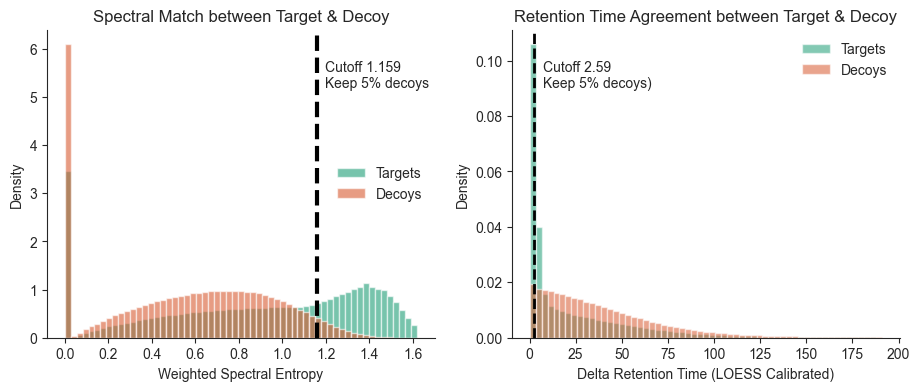

In [457]:
# Visualize the decoy-calibrated rescue thresholds 

ent_t = [] # t = target 
ent_d = [] # d = decoy
rt_t = [] 
rt_d = [] 
for frag_dir in frag_dir_list:
    for f in glob(frag_dir + '*_edited.pin'):
        d = pd.read_csv(f, sep='\t', usecols=['Label', 'weighted_spectral_entropy', 'delta_RT_loess'], low_memory=False)
        t = d[d['Label'] == 1]
        dec = d[d['Label'] == -1]

        ent_t.append(t['weighted_spectral_entropy'].values)
        ent_d.append(dec['weighted_spectral_entropy'].values)
        rt_t.append(t['delta_RT_loess'].values)
        rt_d.append(dec['delta_RT_loess'].values)
ent_t = np.concatenate(ent_t)
ent_d = np.concatenate(ent_d)
rt_t = np.concatenate(rt_t)
rt_d = np.concatenate(rt_d)

ent_thresh = np.nanpercentile(ent_d, 100 * (1 - decoy_admit))
rt_thresh = np.nanpercentile(rt_d, 100 * decoy_admit)

# plotting 
target_color, decoy_color = '#1D9E75', '#D85A30'
fig, axes = plt.subplots(1,2, figsize=(11,4))

# entropy panel 
ax = axes[0]
bins = np.linspace(0, np.nanpercentile(ent_t, 99.5), 60)
ax.hist(ent_t, bins=bins, density=True, color=target_color, alpha=0.6, label='Targets')
ax.hist(ent_d, bins=bins, density=True, color = decoy_color, alpha=0.6, label='Decoys')
ax.axvline(ent_thresh, color='k', ls='--', lw=3)
ax.annotate(f"Cutoff {ent_thresh:.3f}\nKeep {decoy_admit:.0%} decoys", xy=(ent_thresh, ax.get_ylim()[1]*0.9),
                xytext=(6,0), textcoords="offset points", va="top", fontsize=10)
ax.set_xlabel("Weighted Spectral Entropy")
ax.set_ylabel("Density")
ax.set_title("Spectral Match between Target & Decoy")
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# retention time panel 
ax = axes[1]
bins = np.linspace(0, np.nanpercentile(rt_d, 99), 60)
ax.hist(rt_t, bins=bins, density=True, color=target_color, alpha=0.55, label='Targets')
ax.hist(rt_d, bins=bins, density=True, color=decoy_color, alpha=0.55, label='Decoys')
ax.axvline(rt_thresh, color='k', ls='--', lw=2)
ax.annotate(f'Cutoff {rt_thresh:.2f}\nKeep {decoy_admit:.0%} decoys)',
            xy=(rt_thresh, ax.get_ylim()[1]*0.9), xytext=(6, 0),
            textcoords='offset points', va='top', fontsize=10)
ax.set_xlabel("Delta Retention Time (LOESS Calibrated)")
ax.set_ylabel("Density")
ax.set_title("Retention Time Agreement between Target & Decoy")
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig(PLOT_DIR + "rescue_threshold_target_decoy.pdf", bbox_inches='tight')
plt.savefig(PLOT_DIR + "rescue_threshold_target_decoy.png", dpi=600, bbox_inches='tight')


# report keep-rates at these thresholds
print(f'entropy >= {ent_thresh:.3f}: keeps {(ent_t>=ent_thresh).mean():.1%} targets, {(ent_d>=ent_thresh).mean():.1%} decoys')
print(f'delta_RT <= {rt_thresh:.2f}:  keeps {(rt_t<=rt_thresh).mean():.1%} targets, {(rt_d<=rt_thresh).mean():.1%} decoys')

In [458]:
# Apply filtering
SAAP_quant_df = SAAP_quant_df[SAAP_quant_df['keep_localization']].copy()
print(SAAP_quant_df)

             Dataset               MTP_seq                BP_seq  aa_sub  \
0              Aorta              PATVSLPR              VATVSLPR  V to P   
1              Aorta              PATVSLPR              VATVSLPR  V to P   
2              Aorta              PATVSLPR              VATVSLPR  V to P   
3              Aorta              PATVSLPR              VATVSLPR  V to P   
4              Aorta              PATVSLPR              VATVSLPR  V to P   
...              ...                   ...                   ...     ...   
32168  hippocampus_2  TIGGGDDSFTTFFSETGAGK  TIGGGDDSFTTFFCETGAGK  C to S   
32169  hippocampus_2  TIGGGDDSFTTFFSETGAGK  TIGGGDDSFTTFFCETGAGK  C to S   
32170  hippocampus_2  TIGGGDDSFTTFFSETGAGK  TIGGGDDSFTTFFCETGAGK  C to S   
32171  hippocampus_2  TIGGGDDSFTTFFSETGAGK  TIGGGDDSFTTFFCETGAGK  C to S   
32172  hippocampus_2  TIGGGDDSFTTFFSETGAGK  TIGGGDDSFTTFFCETGAGK  C to S   

      tmt_set  Positional_probability  spectral_entropy  delta_RT  SAAP_PEP  \
0       

# 2. Visualize Validation Metrics

## Data completeness

In [459]:
# Assess data completeness of SAAPs in SAAP_quant_df 
print(f'{len(SAAP_quant_df):,} total SAAP observations in original dataset')
SAAP_quant_complete_df=SAAP_quant_df.dropna()
print(f'{len(SAAP_quant_complete_df):,} fully complete SAAP observations retained')
print(f'{100*(len(SAAP_quant_complete_df)/len(SAAP_quant_df)):.2f}% original dataset completeness')

# Option to replace read-in SAAP_quant_df with SAAP_quant_df that has 100% data completeness
# SAAP_quant_df = SAAP_quant_complete_df 

16,908 total SAAP observations in original dataset
15,160 fully complete SAAP observations retained
89.66% original dataset completeness


### Positional probability filtering

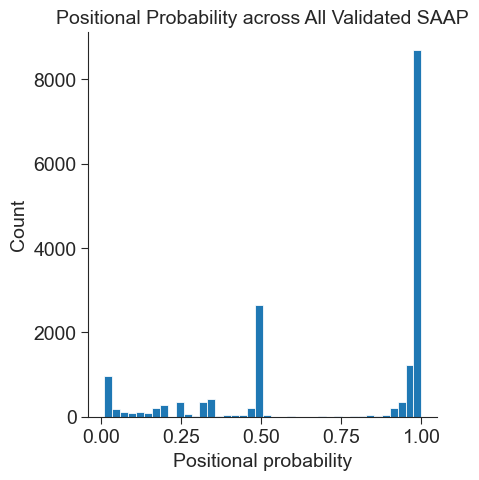

In [460]:
# Filtered distribution 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
loc_df=SAAP_quant_df['Positional_probability']
loc_df=(loc_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=loc_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('Positional probability',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('Positional Probability across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.png',dpi=600,bbox_inches='tight')

### PEP filtering

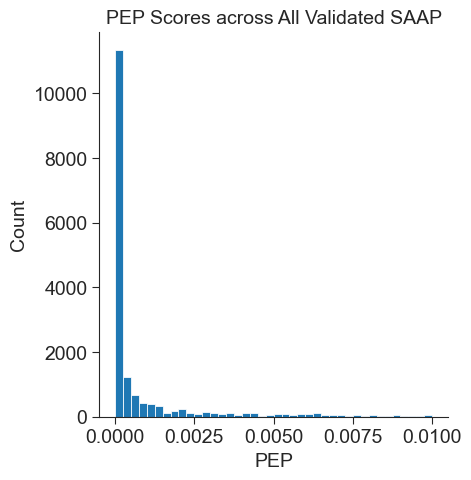

In [461]:
# Plot PEP distribution for all SAAP 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
pep_df=SAAP_quant_df['SAAP_PEP']
pep_df=(pep_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=pep_df,bins=40,color='#1f78b4',alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('PEP',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('PEP Scores across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'PEP_all_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'PEP_all_AAS.png',dpi=600,bbox_inches='tight')

## Dataset Metrics

In [462]:
# function to get number of peptides in each filtration category 

def get_filter_df(data_dir, samples):
    """ 
    function that reads in output from decode pipeline to get number of peptides in each category
    Input: directory with output files for dataset, dataset samples/TMT set names
    output: dataframe with the number of peptides in each category
    """
    dp_ev_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p', 'rb'))
    dp_dict = pickle.load(open(data_dir+'DP_dict.p', 'rb'))
    mtp_dict = pickle.load(open(data_dir+'MTP_dict.p', 'rb'))
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb')) # dictionary of putative substitutions that pass FDR correction
    substr_dict = pickle.load(open(data_dir+'genome_substr_dict.p', 'rb'))
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    
    rows = []
    for s in samples:
        seqs = [[x for y in list(mtp_dict[s]['mistranslated sequence'].values()) for x in y] for s in samples]
        seqs = [x for y in seqs for x in y]
        if 'all_6frame_seqs' in substr_dict.keys():
            homolog_seqs = substr_dict['all_6frame_seqs']
        else:
            homolog_seqs = substr_dict['all_frame6_seqs']
        seqs_hom = [x for x in seqs if x in homolog_seqs]
        
        n_main = len(dp_ev_dict[s]['Raw file'])
        n_dp = len(dp_dict[s]['Raw file'])
        n_ptm = len(ptm_dict[s]['Raw file'])
        n_aas = len(mtp_dict[s]['Raw file'])
        n_nohom = len([i for i,x in mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_hc = len([i for i,x in hc_mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_val = len(val_mtp_dict[s]['Raw file'])

        rows.append([s, n_main, n_dp, n_ptm, n_aas, n_nohom, n_hc, n_val])
    df = pd.DataFrame(rows, columns=['TMT set', 'Main peptides', 'DP', 'PTM', 'AAS', 'Non-homologous', 'High-confidence', 'Validated'])

    return(df)

<Figure size 1100x500 with 0 Axes>

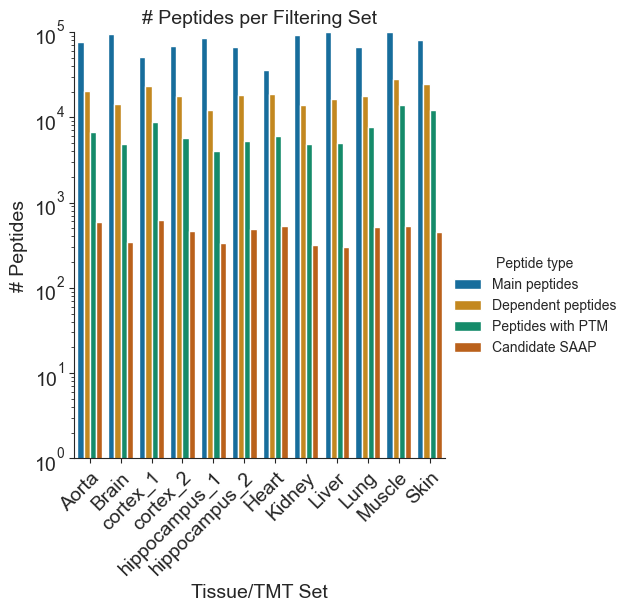

In [463]:
# N peptide IDs through filtering steps for QC figure 

# get number of samples in each dataset
n_samples_data = []
total = 0
for ds in datasets:
    sample_map = sample_map_list[datasets.index(ds)]
    samples = sample_map['sample_name'].values
    
    n_samples = len(samples)
    total += n_samples
    n_samples_data.append([ds, n_samples])

n_samples_df = pd.DataFrame(n_samples_data, columns=['Dataset','N samples'])
# print(n_samples_df)
n_samples_df.to_excel(OUTDIR+'N_samples_in_datasets.xlsx')

# create a dict containing dfs generated above per dataset 
filter_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    filter_dict[ds] = get_filter_df(data_dir, samples)

for ds in datasets:
    filter_dict[ds]['Dataset'] = [ds]*len(filter_dict[ds])
pickle.dump(filter_dict, open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'wb'))
# filter_dict = pickle.load(open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))))

all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set','Dataset','Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
# print(sum_dict)

# filtering modified peptides to candidate SAAP
barplot_rows = []
for i, row in all_df.iterrows():
    barplot_rows.append([row['Dataset'], row['Main peptides'], 'Main peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['DP'], 'Dependent peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['PTM'], 'Peptides with PTM', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['High-confidence'], 'Candidate SAAP', row['TMT set']])
barplot_df = pd.DataFrame(barplot_rows, columns=['Dataset', 'N peptide IDs', 'Peptide type', 'TMT set'])

# plotting 
plt.figure(figsize=(11,5))
sns.set_style(style='ticks')
ax = sns.catplot(data=barplot_df,kind='bar',
                 x='Dataset',y='N peptide IDs',
                 hue='Peptide type',palette='colorblind',
                 alpha=1, order=datasets)

ax.set(yscale='log', ylim=(1, 1e5))
ax.set_axis_labels('Tissue/TMT Set', '# Peptides',fontsize=14)
for ax in ax.axes.flat:
    ax.set_ylabel('# Peptides', fontsize=14)
    ax.tick_params(axis='x',labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax.set_title('# Peptides per Filtering Set',fontsize=14)

plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [464]:
#filter_dict = pickle.load(open(outdir+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))
all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set', 'Dataset', 'Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
        
print(sum_dict)

{'Main peptides': np.int64(917908), 'DP': np.int64(224894), 'PTM': np.int64(84538), 'AAS': np.int64(5898), 'Non-homologous': np.int64(5897), 'High-confidence': np.int64(5500), 'Validated': np.int64(3018)}


## Percentage of candidate SAAPs validated through database search 

In [465]:
# functions to get number of unique candidate substituted peptides and number of unique validated substituted peptides for each sample in each dataset
def get_n_unq_seqs(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique candidate substituted peptides
    """
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    s_seqs = [x for y in hc_mtp_dict[s]['mistranslated sequence'].values() for x in y]
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

def get_n_unq_val(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique validated substituted peptides
    """
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p', 'rb'))
    s_seqs = list(val_mtp_dict[s]['mistranslated sequence'].values())
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

Aorta
Brain
cortex_1
cortex_2
hippocampus_1
hippocampus_2
Heart
Kidney
Liver
Lung
Muscle
Skin


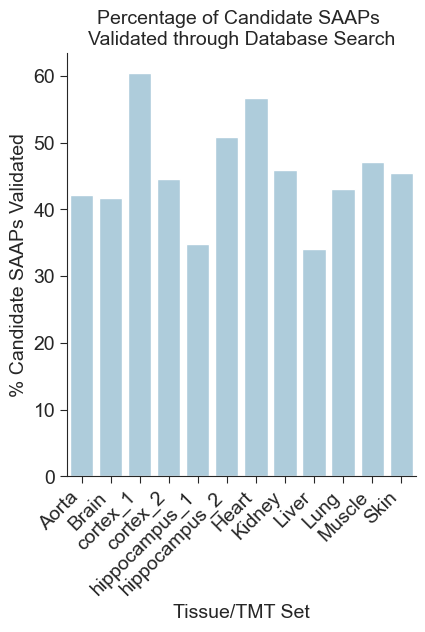

In [466]:
# Percentage of candidate SAAPs validated through database search 

# get dataframe with number of unique substituted peptides, candidate and validated
rows = []
cols = ['Dataset', 'N SAAP sequences', 'SAAP sequence type', 'TMT set']

for i,ds in enumerate(datasets):
    samples=samples_list[i]
    data_dir=data_dir_list[i]
    for s in samples:
        n_seqs = get_n_unq_seqs(data_dir,s)
        n_val_seqs = get_n_unq_val(data_dir,s)
        rows.append([ds,n_seqs,'Candidate',s])
        rows.append([ds,n_val_seqs,'Validated',s])
plt_df = pd.DataFrame(rows,columns=cols)

# get dataframe with percentage of peptides validated and percentage of peptides with no genome homology (from ds_filter_dict.p generated above)
pcnt_rows = []
for i,ds in enumerate(datasets):
    print(ds)
    data_dir = data_dir_list[i]
    samples = samples_list[i]
    ds_plt_df = plt_df.loc[plt_df['Dataset']==ds,:]
    ds_filter_dict = filter_dict[ds]
    for j,s in enumerate(samples):
        s_df = ds_plt_df.loc[ds_plt_df['TMT set']==s,:]
        n_cand = s_df.loc[s_df['SAAP sequence type']=='Candidate', 'N SAAP sequences'].values[0]
        n_val = s_df.loc[s_df['SAAP sequence type']=='Validated', 'N SAAP sequences'].values[0]
        val_pcnt = 100*(n_val/n_cand)
        n_aas = ds_filter_dict['AAS'][j]
        pcnt_rows.append([ds,s, val_pcnt, 'Validated SAAP'])
pcnt_df = pd.DataFrame(pcnt_rows, columns=['Dataset', 'TMT set', '% peptides', '% type'])
nonrectum_row = [i for i,row in pcnt_df.iterrows() if (row['TMT set']!='rectum') and (row['TMT set']!='bonemarrow')] # too little data, removed these tissues from analysis
pcnt_df = pcnt_df.loc[nonrectum_row]
pcnt_df.to_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx')
avg_pcnt_df = pcnt_df.groupby(['Dataset', 'TMT set', '% type'], as_index=False).agg({'% peptides': 'mean'})
# pcnt_df = pd.read_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx', index_col=0)

# plot percentage of candidate SAAPs validated across samples
sns.set_style(style='ticks')
fix,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=avg_pcnt_df,x='Dataset',
            y='% peptides',hue='% type',
            palette='Paired', order=datasets)
ax.get_legend().remove()
sns.despine()
plt.yticks(fontsize=14)
plt.xticks(rotation=45,fontsize=14,ha='right')
plt.tick_params(axis='both',length=5)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.title('Percentage of Candidate SAAPs \nValidated through Database Search',fontsize=14)
plt.ylabel('% Candidate SAAPs Validated',fontsize=14)

plt.savefig(PLOT_DIR+'Percent_validated_allDS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Percent_validated_allDS.png',dpi=600,bbox_inches='tight')

## Fragment ion support for substitution site

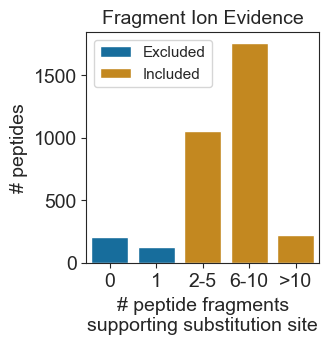

In [467]:
# Fragment ion support at substitution site 
fig,ax=plt.subplots(figsize=(3,3))
plot_df = frag_df
sns.set_style('ticks')
sns.barplot(data=plot_df, x='Bin', y='Count', hue='Used', dodge=False, palette='colorblind')
ax.tick_params('both', labelsize=14)

plt.ylabel('# peptides', fontsize=14)
sns.set_style(style='ticks')
handles, labels = ax.get_legend_handles_labels()
plt.title(f'Fragment Ion Evidence',fontsize=14)
plt.legend(handles=handles, loc='upper left', labels=['Excluded', 'Included'], fontsize=11)
plt.xlabel('# peptide fragments\nsupporting substitution site', fontsize=14)

plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.png',dpi=600,bbox_inches='tight')

## Running mean of PEP computed only across SAAP

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/1426888465.py:15: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/1426888465.py:16: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/1426888465.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/1426888465.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')


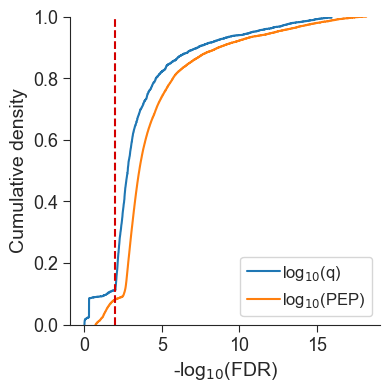

In [468]:
# cumulative density of q-values and PEPs across all datasets and samples
# plot the p-values determined by MaxQuant and the q-values determined from only the substituted peptides
plot_rows = []
plot_cols = ['Dataset', 'TMT/Tissue', 'q-value', 'PEP']
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    qmtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    for s in samples:
        s_dict = qmtp_dict[s]
        for k,v in s_dict['Posterior subs probability'].items():
            plot_rows.append([ds, s, 1-v[0], s_dict['q-value'][k][0]])
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)

plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
fig,ax = plt.subplots(figsize=(4,4))
sns.set_style(style='ticks')
sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')
plt.ylabel('Cumulative density', fontsize=14)
plt.xlabel('-log$_{10}$(FDR)', fontsize=14)
ax.tick_params('both', labelsize=13)
sns.despine()
plt.plot((2, 2), plt.ylim(), '--', color="#d40000")
plt.tick_params(axis='both', length=5)
plt.legend(loc='lower right', fontsize=12, handletextpad=0.1)

plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.png',dpi=600, bbox_inches='tight')

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:58: SyntaxWarning: invalid escape sequence '\g'
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/2872710814.py:35: SyntaxWarning: invalid escape sequence '\g'
  all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/2872710814.py:43: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/2872710814.py:58: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = hi

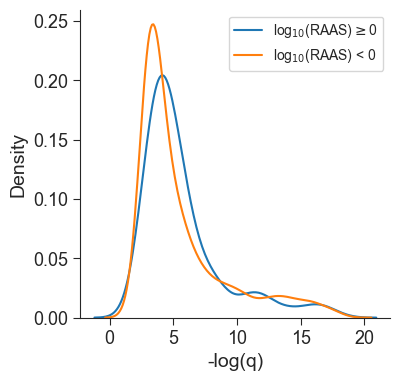

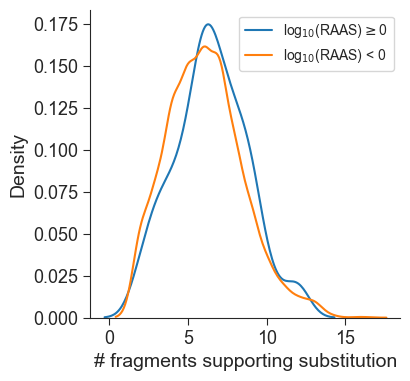

In [469]:
# cumulative density of q-values and PEPs across all datasets and samples stratified by RAAS
# generate a dictionary with PEP values and N fragments for all SAAP in all datasets 
paas_pep_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    mtp_dict = pickle.load(open(data_dir + 'Ion_validated_MTP_dict.p', 'rb'))
    mtp_quant_dict = pickle.load(open(data_dir + 'MTP_quant_dict.p', 'rb'))

    plot_rows = []
    plot_cols = ['Dataset', 'Sample', 'SAAP', 'SAAP_val_idx', 'DP PEP', 'SAAP PEP', 'SAAP q', 'SAAP Precursor Intensity','BP Precursor Intensity', 'Precursor RAAS', 'N fragments']
    for s in samples:
        s_dict = mtp_dict[s]
        for k, paas in s_dict['mistranslated sequence'].items():
            paas_pep = s_dict['Posterior subs probability'][k]
            paas_q = s_dict['q-value'][k]
            dp_pep = s_dict['DP PEP'][k]
            n_frags = s_dict['fragment_evidence'][k]
            q_dict = [i for i,v in mtp_quant_dict.items() if v['MTP_seq']==paas]
            if len(q_dict)>0:
                q_dict = mtp_quant_dict[q_dict[0]]
                paas_prec = q_dict['MTP_PrecInt'][s]
                bp_prec = q_dict['BP_PrecInt'][s]
                raas = q_dict['Prec_ratio'][s]
                if (~np.isnan(raas)) and (~np.isinf(raas)):
                    plot_rows.append([ds, s, paas, k, dp_pep, paas_pep, paas_q, paas_prec, bp_prec, raas, n_frags])
    plot_df = pd.DataFrame(plot_rows, columns=plot_cols)   
    paas_pep_dict[ds] = plot_df

pickle.dump(paas_pep_dict, open(OUTDIR+'SAAP_PEP_dfs.p', 'wb'))

# create data frame for plot 
all_ds_plot_df = pd.concat([v for k,v in paas_pep_dict.items()])
all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
all_ds_plot_df = all_ds_plot_df.loc[all_ds_plot_df['SAAP q']<=0.01]

# plot histogram of confidence values stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
all_ds_plot_df['-log q'] = [-np.log10(x) for x in all_ds_plot_df['SAAP q']]
high_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']>=0]
low_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']<0]
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='-log q', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('-log(q)', fontsize=14)
plt.legend(fontsize=10)
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.png', dpi=600, bbox_inches='tight')


# plot histogram of N fragments on substitution site stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='N fragments', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='N fragments', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# fragments supporting substitution', fontsize=14)
# plt.yticks([0,0.03,0.06,0.09,0.12])
plt.tick_params(axis='both', length=5)
plt.legend(loc='upper right', fontsize=10)

plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.png',dpi=600, bbox_inches='tight')

## Mass error analysis 

In [470]:
# Group Tissues Together 
def simplify_dataset(x):
    if x.startswith('cortex'):
        return 'Cortex'
    elif x.startswith('hippocampus'):
        return 'Hippocampus'
    elif x.startswith('striatum'):
        return 'Striatum'
    elif x.startswith('kidney'):
        return 'Kidney'
    return x

def simplify_brain(x):
    if x.startswith('Cortex'):
        return 'Brain'
    elif x.startswith('Hippocampus'):
        return 'Brain'
    elif x.startswith('Striatum'):
        return 'Brain'
    

SAAP_quant_df_grouped = SAAP_quant_df.copy()
SAAP_quant_df_grouped['Dataset'] = SAAP_quant_df_grouped['Dataset'].apply(simplify_dataset)
SAAP_quant_df = SAAP_quant_df_grouped

datasets = ['Aorta', 'Brain', 'Heart', 'Kidney', 'Lung', 'Liver', 'Muscle', 'Skin', 'Cortex', 'Hippocampus']
SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds] for ds in datasets]

In [471]:
# Function to find median mass error for a SAAP
def saap_mass_error(saap, s_saap_dict):
    """Median aa-substitution mass error (ppm) for a SAAP; NaN if the SAAP is absent."""
    saap_idx = [k for k, v in s_saap_dict['mistranslated sequence'].items() if v == saap]
    if not saap_idx:
        print(f"WARNING: SAAP {saap} not found in mistranslated sequence")
        return np.nan
    return np.median([s_saap_dict['aa subs mass error (ppm)'][k] for k in saap_idx])

Aorta S1 rows: 1776
    MTP_seq  Reporter_RAAS
0  PATVSLPR            NaN
1  PATVSLPR            NaN
2  PATVSLPR            NaN
3  PATVSLPR            NaN
4  PATVSLPR            NaN
High SAAP: ['SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'SIDDLEEK', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'VVLEGPATWGFR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'DLYANDVLSGGTTMYPGIADR', 'DLYANDVLSGGTTMYPGIADR', 'DLYANDVLSGGTTMYPGIADR', 'DLYANDVLSGGTTMYPGIADR', 'D

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/1028682587.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  plot_df = pd.concat(plot_df_list)


ValueError: cannot reindex on an axis with duplicate labels

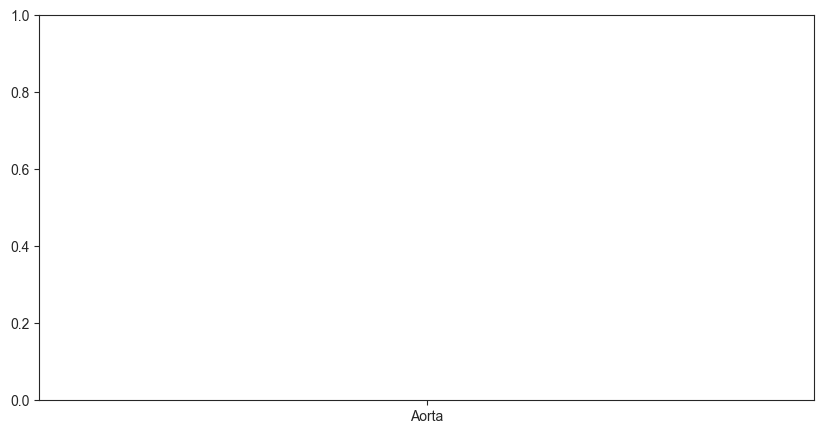

In [472]:
# mass error analysis
SAAP_quant_df['tmt_set'] = SAAP_quant_df['tmt_set'].str.strip("[]'\"")

# create a dictionary with mass errors of SAAP with high and low RAAS
mass_err_dict = {ds:{'High RAAS mass error':[], 'Low RAAS mass error':[]} for ds in datasets}
for gran, data_dir in data_dir_by_ds.items():
    group = simplify_dataset(gran)
    ds_prec_df = SAAP_quant_df.loc[SAAP_quant_df['Dataset']==group]   
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_by_ds[gran]
    # print(samples)
    for s in samples:
        s_saap_dict = saap_dict[s]
        # print(s_saap_dict.keys())
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            s_prec_df = ds_prec_df.loc[ds_prec_df['tmt_set']==s]
            print(f"{group} {s} rows: {len(s_prec_df)}")
            print(s_prec_df[['MTP_seq', 'Reporter_RAAS']].head())

            high_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']>=0, 'MTP_seq'].to_list()
            low_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']<0, 'MTP_seq'].to_list()
            print(f"High SAAP: {high_saap}")
            print(f"Low SAAP: {low_saap}")

            high_errs = [saap_mass_error(saap, s_saap_dict) for saap in high_saap]
            low_errs = [saap_mass_error(saap, s_saap_dict) for saap in low_saap]
            mass_err_dict[group]['High RAAS mass error']  = mass_err_dict[group]['High RAAS mass error'] + high_errs
            mass_err_dict[group]['Low RAAS mass error']  = mass_err_dict[group]['Low RAAS mass error'] + low_errs 
pickle.dump(mass_err_dict, open(OUTDIR+'High_v_low_RAAS_mass_error_ppm.p','wb'))

# create dataframe for plot
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    high_errs = ds_me_dict['High RAAS mass error']
    low_errs = ds_me_dict['Low RAAS mass error']
    ds_list = [ds]*len(high_errs+low_errs)
    high_str_list = [r'RAAS$\geq$0']*len(high_errs)
    low_str_list = ['RAAS < 0']*len(low_errs)
    ds_plot_df = pd.DataFrame(zip(ds_list, high_errs+low_errs, high_str_list+low_str_list), columns=['Dataset', 'aa subs mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

# plot distributions of mass errors for SAAP with high and low RAAS
fig,ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=plot_df, x='Dataset', hue='Peptide type', y='aa subs mass error (ppm)', linewidth=1, fliersize=3, palette='colorblind')
plt.ylabel('Mass error (ppm)', fontsize=14)
ax.tick_params('both', labelsize=13)
ax.tick_params('x', rotation=45)
plt.xlabel('TMT set',fontsize=14)
plt.ylim(-0.002, 0.005)
plt.legend(loc='lower left', fontsize=12, frameon=False, ncol=1)
plt.title('SAAP mass error by RAAS group, per TMT set', fontsize=14)

plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.png', dpi=600, bbox_inches='tight')

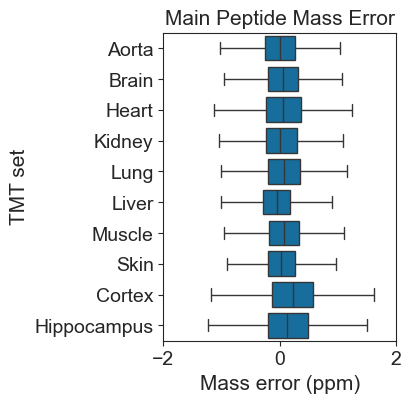

In [ ]:
# Main peptide mass error 
# generate a dictionary with mass error data
mass_err_dict = {ds:{'Main peptide mass error':[], 'SAAP mass error':[]} for ds in datasets}
for gran, data_dir in data_dir_by_ds.items():
    group = simplify_dataset(gran)
    mainpep_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p','rb'))
    for s in samples_by_ds[gran]:
        errs = mainpep_dict[s]['Mass error [ppm]']
        errs = [x for x in errs if np.abs(x)<10000]
        mass_err_dict[group]['Main peptide mass error'] = mass_err_dict[group]['Main peptide mass error']+errs

pickle.dump(mass_err_dict, open(OUTDIR+'Main_peptide_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'Main_peptide_mass_error_ppm.p','rb'))

# plot main peptide mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    main_pep_errs = ds_me_dict['Main peptide mass error']
    saap_errs = [np.abs(x) for x in ds_me_dict['SAAP mass error']]
    saap_errs = saap_errs + [-x for x in saap_errs]
    ds_list = [ds]*len(main_pep_errs+saap_errs)
    main_str_list = ['Main peptide']*len(main_pep_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, main_pep_errs+saap_errs, main_str_list+saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', hue='Peptide type', x='Mass error (ppm)', linewidth=1, fliersize=0, palette='colorblind')
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set', fontsize=15)
plt.xlim([-2,2])
plt.title('Main Peptide Mass Error',fontsize=15)
# plt.legend(loc='lower left', fontsize=14, bbox_to_anchor=(-0.2,0.97), frameon=False, ncol=2, handletextpad=0.1, columnspacing=0.8)
ax.get_legend().remove()

plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.png',dpi=600, bbox_inches='tight')

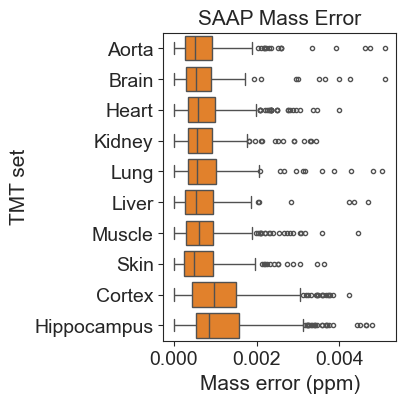

In [ ]:
# SAAP mass error 
mass_err_dict = {ds:{'SAAP mass error':[]} for ds in datasets}
for gran, data_dir in data_dir_by_ds.items():
    group = simplify_dataset(gran)
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    for s in samples_by_ds[gran]:
        s_saap_dict = saap_dict[s]
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            saap_errs = [saap_mass_error(saap, s_saap_dict) for saap in s_saap_dict['mistranslated sequence'].values()]
            mass_err_dict[group]['SAAP mass error'] = mass_err_dict[group]['SAAP mass error']+saap_errs
pickle.dump(mass_err_dict, open(OUTDIR+'SAAP_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'SAAP_mass_error_ppm.p','rb'))

# plot SAAP mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    saap_errs = ds_me_dict['SAAP mass error']
    ds_list = [ds]*len(saap_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, saap_errs, saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)
fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', x='Mass error (ppm)', linewidth=1, fliersize=3, color=colors[1])
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set',fontsize=15)
plt.xscale('linear')
plt.title('SAAP Mass Error',fontsize=15)
# plt.xlim([-0.001,0.0025])

plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.png', dpi=600,bbox_inches='tight')

## N SAAPs post-filtering/validation

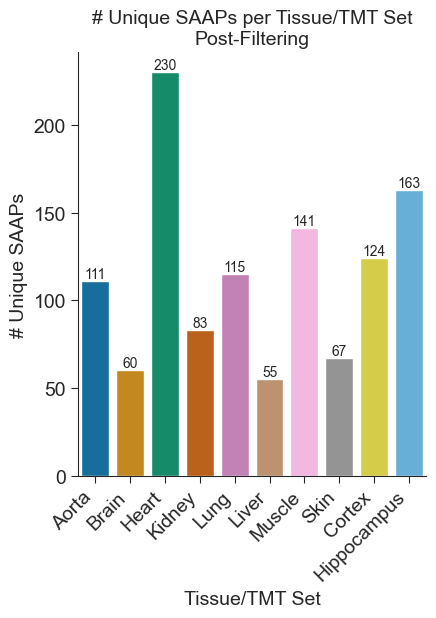

In [ ]:
# N SAAPs per dataset post-filtering
plot_rows = []
plot_cols = ['Dataset','N SAAPs']

for ds in datasets:
    ds_df = SAAP_quant_df[SAAP_quant_df['Dataset']==ds]
    n_saaps = ds_df['MTP_seq'].nunique()
    plot_rows.append([ds,n_saaps])

plot_df = pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')

fig,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Dataset',palette='colorblind',legend=False,order=datasets)
sns.despine()
plt.tick_params('both',labelsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('# Unique SAAPs',fontsize=14)
plt.title('# Unique SAAPs per Tissue/TMT Set\nPost-Filtering',fontsize=14)
plt.tick_params(axis='both',length=5)

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.png',dpi=600,bbox_inches='tight')

# 3. RAAS

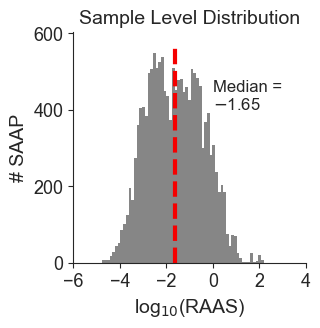

In [ ]:
# sample-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))

ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data

sns.histplot(ratios, color="#868686", bins=60, linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color="#f50000", linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,400), fontsize=12)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_title(r'Sample Level Distribution',fontsize=14)
ax.set_xticks([-6,-4,-2,0,2,4]);
sns.despine()

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.png',dpi=600, bbox_inches='tight')

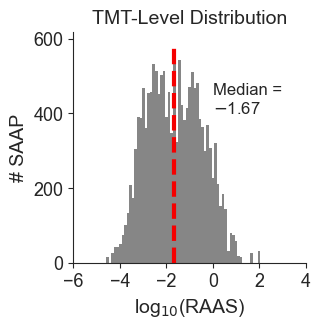

In [ ]:
# tmt-level RAAS distribution - all datasets in one distribution

fig,ax = plt.subplots(figsize=(3,3))

ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_list[i]['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data

sns.histplot(ratios, color='#868686', bins=60, linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#f50000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,400), fontsize=12)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_xticks([-6,-4,-2,0,2,4])
ax.set_title(r'TMT-Level Distribution',fontsize=14)
sns.despine()

plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot.png', dpi=600, bbox_inches='tight')

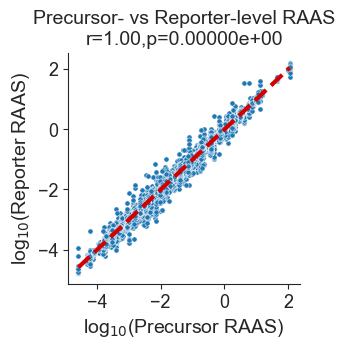

In [ ]:
# Precursor vs Reporter RAAS Level Agreeability
fig,ax = plt.subplots(figsize=(3,3))

raas_df=SAAP_quant_df.copy()
raas_df['log10_Prec_RAAS']=raas_df['Prec_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df['log10_Reporter_RAAS']=raas_df['Reporter_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df=raas_df.dropna(subset=['log10_Prec_RAAS','log10_Reporter_RAAS'])

r,p=sp.stats.pearsonr(raas_df['log10_Prec_RAAS'],raas_df['log10_Reporter_RAAS'])
sns.set_style('ticks')
sns.scatterplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',s=14,alpha=1,color=colors[0],edgecolor='white',linewidth=0.36,ax=ax)
sns.regplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',scatter=False,line_kws={'color':'#d40000','linestyle':'--','linewidth':3,'zorder':10},ax=ax)

ax.tick_params('both',labelsize=13)
plt.xlabel('log$_{10}$(Precursor RAAS)',fontsize=14)
plt.ylabel('log$_{10}$(Reporter RAAS)',fontsize=14)
# ax.set_xticks([-4,-2,0,2])
plt.title(f'Precursor- vs Reporter-level RAAS\nr={r:.2f},p={p:.5e}',fontsize=14)
sns.despine()
plt.savefig(PLOT_DIR+'MS1_MS2_RAAS_correlation.pdf',bbox_inches='tight')

In [ ]:
# Formatting function for bihistogram plots
def bihist(y1, y2, nbins=30, h=None, color='#aaaaaa'):
    """
    Function used to create violin plots as bihistograms with no smoothing.
    h is an axis handle. If not present, a new figure is created.
    """
    if h is None: h = plt.figure().add_subplot(111)
    ymin = np.floor(np.minimum(min(y1), min(y2)))
    ymax = np.ceil(np.maximum(max(y1), max(y2)))
    bins = np.linspace(ymin, ymax, nbins)
    n1, bins1, patch1 = h.hist(y1, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    n2, bins2, patch2 = h.hist(y2, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    xmax = 0
    for i in patch1:
        i.set_edgecolor(None)
        width = i.get_width()
        if width > xmax: xmax = width
    xmin = 0
    for i in patch2:
        i.set_edgecolor(None)
        width = i.get_width()
        width = -width
        i.set_width(width)
        if width < xmin: xmin = width
    h.set_xlim(xmin*1.1, xmax*1.1)
    h.figure.canvas.draw()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/208828733.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


ValueError: min() iterable argument is empty

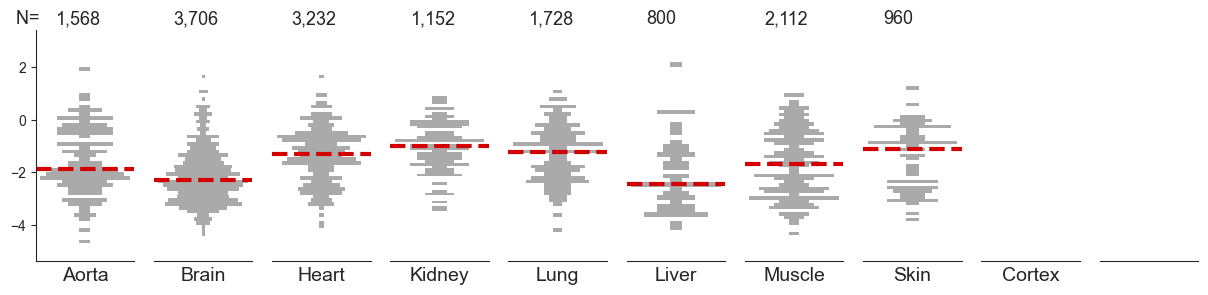

In [ ]:
#TMT-level RAAS distribution (precursor ion RAAS distribution), code adapted from Tsour et al 2024
# N = number of quantified SAAP precursor-ion ratios

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets)*1.5,3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Prec_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [datasets.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians)) # sort by median instead
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.png',dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/4078739248.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


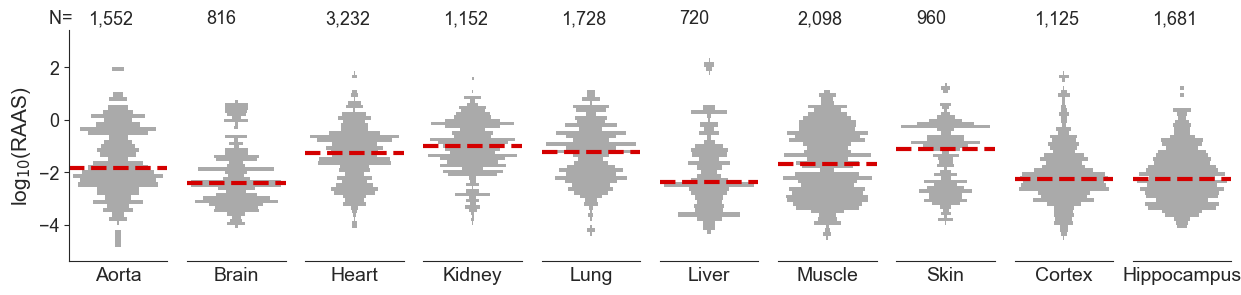

In [ ]:
# sample/reporter ion level RAAS distributions for each dataset, code adapted from Tsour et al 2024
# N = number of quantified SAAP reporter-ion ratios

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets)*1.5,3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [datasets.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_nogrid.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_nogrid.png', dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/2767981948.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


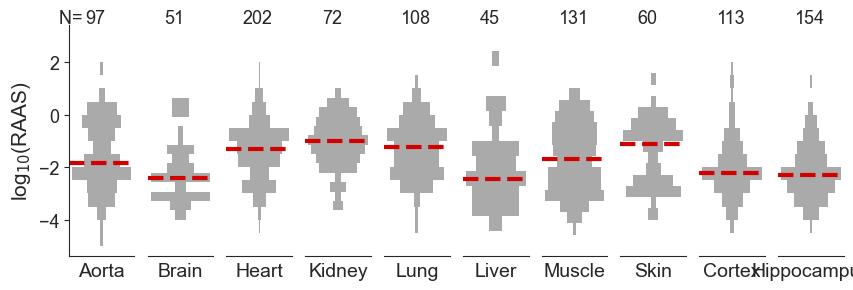

In [ ]:
# Median RAAS distributions for all unique SAAP 
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)
        
medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [datasets.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in saap_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.png', dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_94906/2453639976.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


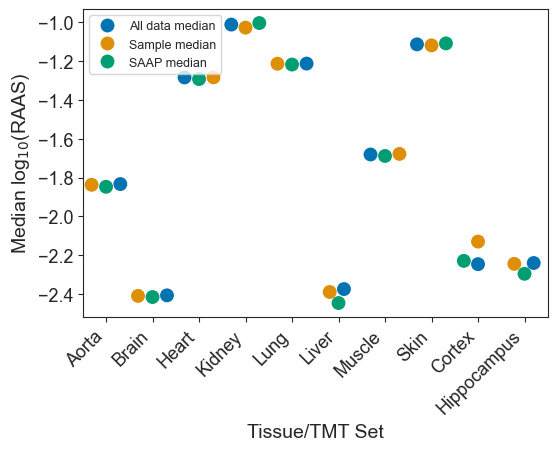

In [ ]:
# Medians for all data, sample, and SAAP-level RAAS 
all_medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
all_medians.append(np.nanmedian(SAAP_quant_df_list[-1]['Reporter_RAAS'].values))

sample_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    samples = list(set(reporter_quant_df['Sample'].values))
    sample_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['Sample']==s, 'Reporter_RAAS'].values) for s in samples]
    sample_median_values_list.append(sample_medians)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)

sample_medians = [np.nanmedian(sample_median_values_list[i]) for i in range(len(datasets))]
saap_medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets))]

plot_rows = []
plot_cols = ['Dataset', 'Median RAAS', 'Median type']
for m, median in enumerate(all_medians):
    plot_rows.append([datasets[m], median, 'All data median'])
for m, median in enumerate(sample_medians):
    plot_rows.append([datasets[m], median, 'Sample median'])
for m, median in enumerate(saap_medians):
    plot_rows.append([datasets[m], median, 'SAAP median'])
    
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)    

fig,ax = plt.subplots(figsize=(6,4))
sns.swarmplot(data=plot_df, x='Dataset', y='Median RAAS', hue='Median type', s=10,
              palette='colorblind',order=datasets)
plt.legend(loc='upper left',title='', fontsize=9)
ax.tick_params('both', labelsize=13)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median log$_{10}$(RAAS)', fontsize=14)
plt.xlabel('Tissue/TMT Set',fontsize=14)

plt.savefig(PLOT_DIR+'RAAS_distribution_median_comparison_swarmplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'RAAS_distribution_median_comparison_swarmplot.png', dpi=600, bbox_inches='tight')